# Эмпирическая сложность минимизации PT-DFA

Ноутбук генерирует воспроизводимые ДКА с 50% заполнением частичной функции переходов и ДКА с полной функцией переходов, запускает проектный `PTDFAMinimizer` и сравнивает медианное время работы с оценками $m\log_2 n$ и $|\Sigma|n\log_2 n$. Теоретические кривые приводятся к миллисекундам общим коэффициентом и не являются абсолютным прогнозом времени.

In [51]:
from __future__ import annotations

import math
import random
import statistics
import sys
import time
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt

# Ячейка работает как из каталога проекта, так и из notebooks/.
cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / 'src' / 'dfa_app').exists() else cwd.parent
SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from dfa_app.algorithms.base import MinimizationResult
from dfa_app.algorithms.pt_dfa_minimizer import PTDFAMinimizer
from dfa_app.domain.models import DFA
from dfa_app.domain.validation import validate_dfa

SEED = 20260711
QUICK_SIZES = [32, 64, 128, 256, 512]
LONG_SIZES = [32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 16384*2, 16384*4, 16384*8]
SIZES = LONG_SIZES  # замените на QUICK_SIZES для быстрого прогона
ALPHABET_SIZE = 4
AUTOMATA_PER_SIZE = 10
REPEATS = 10

assert ALPHABET_SIZE >= 2
assert SIZES and len(SIZES) == len(set(SIZES))
assert all((n * ALPHABET_SIZE) % 2 == 0 for n in SIZES)
assert REPEATS >= 2 and AUTOMATA_PER_SIZE >= 1
print(f'Корень проекта: {PROJECT_ROOT}')

Корень проекта: D:\Projects\DFA


## Генерация автоматов

Цепочка из $n-1$ переходов проходит через все состояния и заканчивается в единственном финальном состоянии. Поэтому каждое состояние достижимо из начального и продуктивно. Затем добавляются случайные уникальные переходы до точного значения $m=0.5n|\Sigma|$ или $m=n|\Sigma|$.

In [52]:
def generate_dfa(
    n: int,
    alphabet_size: int,
    mode: str,
    seed: int,
) -> DFA:
    if n < 2:
        raise ValueError('n должно быть не меньше 2')
    if alphabet_size < 1:
        raise ValueError('alphabet_size должен быть положительным')
    if mode not in {'sparse', 'full'}:
        raise ValueError("mode должен быть 'sparse' или 'full'")
    rng = random.Random(seed)
    states = tuple(f'q{i}' for i in range(n))
    alphabet = tuple(f'a{i}' for i in range(alphabet_size))
    transitions = {}

    # Цепочка гарантирует достижимость и продуктивность всех состояний.
    for i in range(n - 1):
        transitions[(states[i], alphabet[0])] = states[i + 1]

    capacity = n * alphabet_size
    if mode == 'sparse' and capacity % 2:
        raise ValueError('Для точного m = 0.5*n*|Sigma| произведение n*|Sigma| должно быть чётным')
    target_m = capacity if mode == 'full' else capacity // 2
    if target_m < n - 1:
        raise ValueError('Целевая плотность недостаточна для достижимости всех состояний')
    available_keys = [
        (state, symbol)
        for state in states
        for symbol in alphabet
        if (state, symbol) not in transitions
    ]
    rng.shuffle(available_keys)
    for key in available_keys[:target_m - len(transitions)]:
        transitions[key] = rng.choice(states)

    final_states = frozenset({states[-1]})
    dfa = DFA(states, alphabet, transitions, states[0], final_states)
    validate_dfa(dfa)
    return dfa


def expected_transition_count(n: int, alphabet_size: int, mode: str) -> int:
    capacity = n * alphabet_size
    if mode == 'sparse' and capacity % 2:
        raise ValueError('n*|Sigma| должно быть чётным')
    return capacity if mode == 'full' else capacity // 2


# Быстрые проверки генератора и воспроизводимости.
for mode in ('sparse', 'full'):
    first = generate_dfa(16, ALPHABET_SIZE, mode, SEED)
    second = generate_dfa(16, ALPHABET_SIZE, mode, SEED)
    assert first == second
    assert len(first.transitions) == expected_transition_count(16, ALPHABET_SIZE, mode)
    result = PTDFAMinimizer().minimize(first)
    assert isinstance(result, MinimizationResult)
    validate_dfa(result.dfa)
print('Генераторы и минимизация небольших автоматов проверены.')

Генераторы и минимизация небольших автоматов проверены.


## Измерение времени

Автомат создаётся и проверяется до запуска таймера. Для каждого экземпляра выполняется один прогрев, затем несколько независимых измерений `perf_counter_ns`; результат экземпляра — медиана этих измерений. Межквартильный интервал далее вычисляется между медианами разных сгенерированных автоматов одного режима и размера.

In [53]:
def quartiles(values: list[float]) -> tuple[float, float]:
    cuts = statistics.quantiles(values, n=4, method='inclusive')
    return cuts[0], cuts[2]


def benchmark_dfa(dfa: DFA, repeats: int = REPEATS) -> dict[str, float | int]:
    minimizer = PTDFAMinimizer()
    minimizer.minimize(dfa)  # прогрев вне измерений
    elapsed_ms = []
    minimized_size = 0
    for _ in range(repeats):
        started = time.perf_counter_ns()
        result = minimizer.minimize(dfa)
        elapsed_ms.append((time.perf_counter_ns() - started) / 1_000_000)
        minimized_size = result.dfa.size
    return {
        'median_ms': statistics.median(elapsed_ms),
        'minimized_n': minimized_size,
    }


def run_experiment(sizes: list[int] = SIZES) -> list[dict[str, float | int | str]]:
    rows = []
    for mode_index, mode in enumerate(('sparse', 'full')):
        for n in sizes:
            for sample in range(AUTOMATA_PER_SIZE):
                sample_seed = SEED + mode_index * 10_000_000 + n * 1_000 + sample
                dfa = generate_dfa(n, ALPHABET_SIZE, mode, sample_seed)
                m = len(dfa.transitions)
                assert m == expected_transition_count(n, ALPHABET_SIZE, mode)
                measured = benchmark_dfa(dfa)
                rows.append({
                    'mode': mode, 'alphabet_size': ALPHABET_SIZE,
                    'n': n, 'm': m,
                    'density': m / (n * ALPHABET_SIZE),
                    'sample': sample, 'seed': sample_seed,
                    **measured,
                })
        print(f'Завершён режим: {mode}')
    return rows


results = run_experiment()
print(f'Получено строк результатов: {len(results)}')

Завершён режим: sparse
Завершён режим: full
Получено строк результатов: 260


In [54]:
def aggregate(rows):
    grouped = defaultdict(list)
    for row in rows:
        grouped[(row['mode'], row['n'])].append(row)
    summary = []
    for (mode, n), group in sorted(grouped.items()):
        times = [row['median_ms'] for row in group]
        q1, q3 = quartiles(times) if len(times) > 1 else (times[0], times[0])
        summary.append({
            'mode': mode, 'alphabet_size': group[0]['alphabet_size'],
            'n': n, 'm': group[0]['m'],
            'density': group[0]['density'],
            'median_ms': statistics.median(times),
            'q1_ms': q1, 'q3_ms': q3,
            'minimized_n': round(statistics.median(row['minimized_n'] for row in group)),
        })
    return summary


summary = aggregate(results)
header = f"{'режим':<12} {'|Sigma|':>7} {'n':>6} {'m':>8} {'плотн.':>9} {'медиана, мс':>13} {'IQR, мс':>20} {'n после':>9}"
print(header)
print('-' * len(header))
for row in summary:
    interval = f"[{row['q1_ms']:.3f}; {row['q3_ms']:.3f}]"
    print(f"{row['mode']:<12} {row['alphabet_size']:>7} {row['n']:>6} {row['m']:>8} {row['density']:>9.2%} "
          f"{row['median_ms']:>13.3f} {interval:>20} {row['minimized_n']:>9}")

режим        |Sigma|      n        m    плотн.   медиана, мс              IQR, мс   n после
-------------------------------------------------------------------------------------------
full               4     32      128   100.00%         0.338       [0.333; 0.356]        32
full               4     64      256   100.00%         0.645       [0.618; 0.662]        64
full               4    128      512   100.00%         1.367       [1.336; 1.385]       128
full               4    256     1024   100.00%         2.699       [2.666; 2.730]       256
full               4    512     2048   100.00%         5.853       [5.750; 6.005]       512
full               4   1024     4096   100.00%        12.238     [12.123; 12.332]      1024
full               4   2048     8192   100.00%        25.310     [25.162; 26.093]      2048
full               4   4096    16384   100.00%        56.691     [55.426; 57.229]      4096
full               4   8192    32768   100.00%       153.417   [152.907; 154.697

## Графики

Первый рисунок показывает непосредственно измеренное время. Полоса — межквартильный разброс между сгенерированными автоматами одного размера.

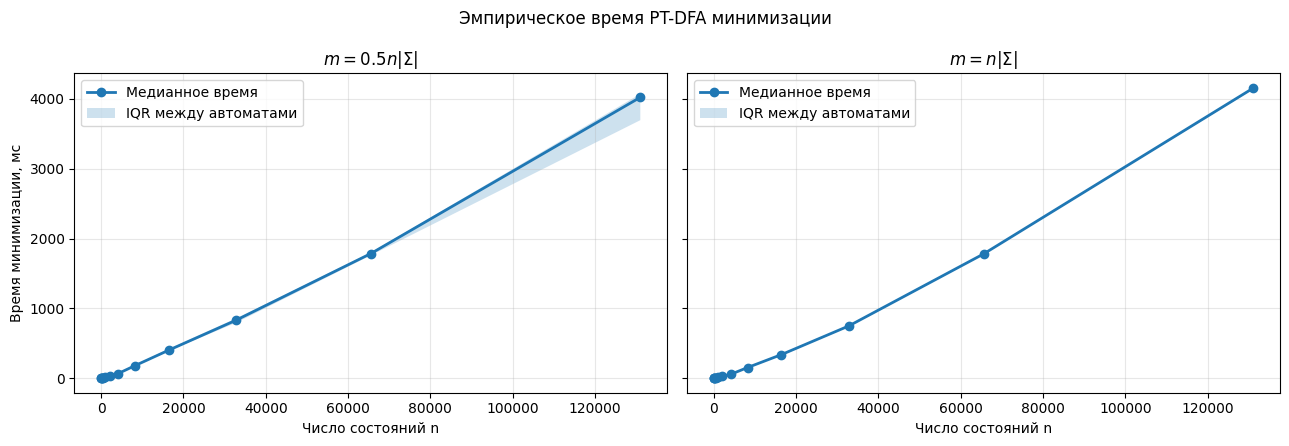

In [55]:
MODE_LABELS = {'sparse': r'$m=0.5n|\Sigma|$', 'full': r'$m=n|\Sigma|$'}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, mode in zip(axes, ('sparse', 'full')):
    data = [row for row in summary if row['mode'] == mode]
    x = [row['n'] for row in data]
    y = [row['median_ms'] for row in data]
    low = [row['q1_ms'] for row in data]
    high = [row['q3_ms'] for row in data]
    ax.plot(x, y, 'o-', linewidth=2, label='Медианное время')
    ax.fill_between(x, low, high, alpha=0.22, label='IQR между автоматами')
    ax.set_title(MODE_LABELS[mode])
    ax.set_xlabel('Число состояний n')
    ax.grid(alpha=0.3)
    ax.legend()
axes[0].set_ylabel('Время минимизации, мс')
fig.suptitle('Эмпирическое время PT-DFA минимизации')
fig.tight_layout()
plt.show()

Второй рисунок сопоставляет измерения с теоретическими объёмами работы $m\log_2 n$ и $|\Sigma|n\log_2 n$. Один общий для обоих режимов коэффициент $c$ подбирается по всем точкам $m\log_2 n$ методом наименьших квадратов без свободного члена: $c=(x^Ty)/(x^Tx)$. Тот же коэффициент применяется к плотной оценке, поэтому высоты линий сопоставимы между панелями и видна цена замены фактического $m$ на $|\Sigma|n$.

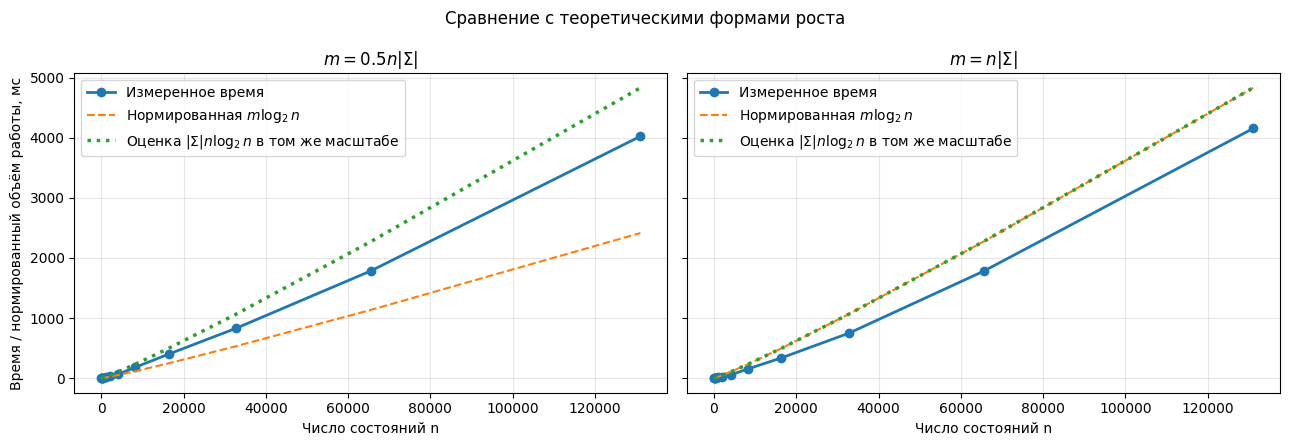

In [56]:
def least_squares_scale(work, elapsed):
    denominator = sum(value * value for value in work)
    return sum(x * y for x, y in zip(work, elapsed)) / denominator


all_m_log_n = [row['m'] * math.log2(row['n']) for row in summary]
all_elapsed = [row['median_ms'] for row in summary]
common_scale = least_squares_scale(all_m_log_n, all_elapsed)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, mode in zip(axes, ('sparse', 'full')):
    data = [row for row in summary if row['mode'] == mode]
    n_values = [row['n'] for row in data]
    elapsed = [row['median_ms'] for row in data]
    m_log_n = [row['m'] * math.log2(row['n']) for row in data]
    sigma_n_log_n = [ALPHABET_SIZE * row['n'] * math.log2(row['n']) for row in data]
    ax.plot(n_values, elapsed, 'o-', linewidth=2, label='Измеренное время')
    ax.plot(n_values, [common_scale * x for x in m_log_n], '--',
            label=r'Нормированная $m\log_2 n$')
    ax.plot(n_values, [common_scale * x for x in sigma_n_log_n], ':', linewidth=2.5,
            label=r'Оценка $|\Sigma|n\log_2 n$ в том же масштабе')
    ax.set_title(MODE_LABELS[mode])
    ax.set_xlabel('Число состояний n')
    ax.grid(alpha=0.3)
    ax.legend()
axes[0].set_ylabel('Время / нормированный объём работы, мс')
fig.suptitle('Сравнение с теоретическими формами роста')
fig.tight_layout()
plt.show()

## Численный анализ результатов

Таблица ниже сравнивает режимы при одинаковом $n$: показывает ускорение от использования 50% переходов и время, делённое на $m\log_2 n$. Последняя величина должна быть примерно постоянной, если измерения хорошо соответствуют оценке $O(m\log n)$. Эмпирический показатель $p$ в модели $t\sim n^p$ вычисляется по первой и последней точкам и служит только сводной характеристикой конечного диапазона.

In [57]:
by_mode_and_n = {(row['mode'], row['n']): row for row in summary}
common_sizes = sorted(
    n for mode, n in by_mode_and_n
    if mode == 'full' and ('sparse', n) in by_mode_and_n
)

print(f"{'n':>7} {'full, мс':>12} {'50%, мс':>12} {'full/50%':>11} "
      f"{'full/(m log n)':>17} {'50%/(m log n)':>17}")
print('-' * 82)
speedups = []
for n in common_sizes:
    full = by_mode_and_n[('full', n)]
    sparse = by_mode_and_n[('sparse', n)]
    speedup = full['median_ms'] / sparse['median_ms']
    speedups.append(speedup)
    full_norm = full['median_ms'] / (full['m'] * math.log2(n))
    sparse_norm = sparse['median_ms'] / (sparse['m'] * math.log2(n))
    print(f"{n:>7} {full['median_ms']:>12.3f} {sparse['median_ms']:>12.3f} "
          f"{speedup:>11.2f} {full_norm:>17.6f} {sparse_norm:>17.6f}")

print(f'\nМедианное ускорение режима 50%: {statistics.median(speedups):.2f}x')
for mode in ('sparse', 'full'):
    data = sorted((row for row in summary if row['mode'] == mode), key=lambda row: row['n'])
    first, last = data[0], data[-1]
    empirical_p = math.log(last['median_ms'] / first['median_ms']) / math.log(last['n'] / first['n'])
    normalized = [row['median_ms'] / (row['m'] * math.log2(row['n'])) for row in data]
    print(
        f"{MODE_LABELS[mode]}: эмпирический p={empirical_p:.3f}; "
        f"разброс t/(m log2 n) = {min(normalized):.6f}..{max(normalized):.6f} мс"
    )

      n     full, мс      50%, мс    full/50%    full/(m log n)     50%/(m log n)
----------------------------------------------------------------------------------
     32        0.338        0.414        0.82          0.000528          0.001293
     64        0.645        0.773        0.83          0.000420          0.001006
    128        1.367        1.563        0.87          0.000381          0.000872
    256        2.699        3.331        0.81          0.000329          0.000813
    512        5.853        7.411        0.79          0.000318          0.000804
   1024       12.238       15.204        0.80          0.000299          0.000742
   2048       25.310       32.172        0.79          0.000281          0.000714
   4096       56.691       66.309        0.85          0.000288          0.000675
   8192      153.417      179.883        0.85          0.000360          0.000845
  16384      337.851      400.664        0.84          0.000368          0.000873
  32768      74

## Интерпретация

- В первом режиме задано ровно $m=0.5n|\Sigma|$, то есть заполнена половина таблицы переходов.
- Во втором режиме задано ровно $m=n|\Sigma|$, то есть функция переходов полная.
- При фиксированном алфавите и фиксированной плотности $m\log n$ и $|\Sigma|n\log n$ пропорциональны, поэтому этот эксперимент не различает их форму роста. Он показывает постоянный выигрыш от учёта фактического числа переходов: в режиме 50% плотная оценка вдвое больше, а в полном режиме оценки совпадают.
- Единый коэффициент нормировки рассчитан по точкам обоих режимов, поэтому теоретические высоты между левой и правой панелями можно сравнивать напрямую.
- Измерения wall-clock чувствительны к загрузке компьютера и реализации Python. Для отчёта следует увеличить `AUTOMATA_PER_SIZE` и `REPEATS`, а для долгого прогона заменить `SIZES` на `LONG_SIZES`.
- Размер минимизированного автомата приведён в таблице как диагностический показатель, но теоретические величины вычисляются по входным $n$ и $m$.